In [ ]:
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

bewerkte_data_dir = '/home/laura/Scriptie/bewerkte_data/THRawS'

X_dataset = np.load(os.path.join(bewerkte_data_dir, 'X_patches_compleet.npy'))
y_dataset = np.load(os.path.join(bewerkte_data_dir, 'y_patches_compleet.npy'))

✅ Dataset geladen! X shape: (180, 256, 256, 3), y shape: (180,)


### 1. Feature Engineering
Een Random Forest kan niet goed overweg met ruwe 2D-plaatjes. We vatten elke patch daarom samen in 4 kenmerken (features) die we extraheren uit de kanalen:
1. **Max B11**: De allerhoogste hitte-waarde in de patch.
2. **Mean B11**: De gemiddelde hitte in de patch.
3. **Max B04**: De felste reflectie in zichtbaar rood licht.
4. **Ratio B11/B08**: De verhouding tussen hitte en normale vegetatie-reflectie.

In [10]:
def extract_features(X_patches, include_leak=False):
    features_list = []
    for patch in X_patches:
        b04 = patch[:, :, 0] # Red
        b08 = patch[:, :, 1] # Infrared
        b11 = patch[:, :, 2] # Heat
        
        if include_leak:
            # --- FEATURE ENGINERING ---
            f1 = np.max(b11)
            f2 = np.mean(b11)
            f3 = np.max(b04)
            f4 = f1 / (np.max(b08) + 1)
        else:
            # --- NORMAL FEATURES ---
            f1 = np.mean(b11)
            f2 = np.std(b11)
            f3 = np.max(b04)
            f4 = np.mean(b11) / (np.mean(b08) + 1)
            
        features_list.append([f1, f2, f3, f4])
        
    return np.array(features_list)

# TRUE for feature engineering (leak)
# FALSE for normal features
FEATURE_ENGINEERING = False 

# Extract features according to choice
X_tabular = extract_features(X_dataset, include_leak=FEATURE_ENGINEERING)

# Correct names for feature importance plots
if FEATURE_ENGINEERING:
    feature_names = ['Max B11 (heat)', 'Mean B11', 'Max Red', 'Ratio Max heat/infrared']
else:
    feature_names = ['Mean B11 (heat)', 'Contrast in heat (Std)', 'Max Red', 'Ratio mean heat/infrared']

X_train, X_test, y_train, y_test = train_test_split(
X_tabular, y_dataset, test_size=0.2, random_state=42, stratify=y_dataset)


--- RESULTS (feature engineering: False) ---
              precision    recall  f1-score   support

    No Event       0.97      0.97      0.97        35
        Fire       0.00      0.00      0.00         1

    accuracy                           0.94        36
   macro avg       0.49      0.49      0.49        36
weighted avg       0.94      0.94      0.94        36



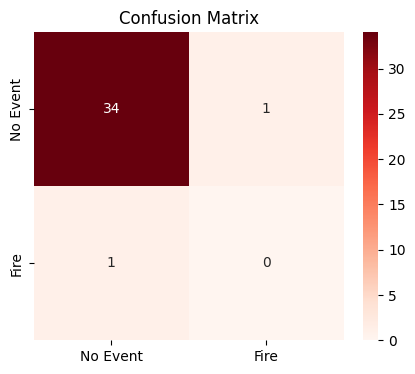

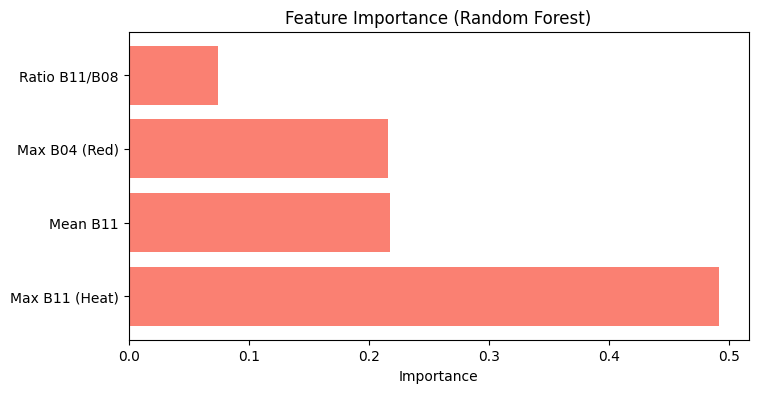

In [13]:
# ==========================================
# --- RANDOM FOREST MODEL ---
# ==========================================
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(f"\n--- RESULTS (feature engineering: {FEATURE_ENGINEERING}) ---")
print(classification_report(y_test, y_pred, target_names=['No Event', 'Fire']))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Event', 'Fire'], yticklabels=['No Event', 'Fire'])
plt.title('Confusion Matrix')
plt.show()

# Showing feature importance
importances = rf.feature_importances_
names = ['Max B11 (Heat)', 'Mean B11', 'Max B04 (Red)', 'Ratio B11/B08']

plt.figure(figsize=(8,4))
plt.barh(names, importances, color='salmon')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.show()


--- RESULTS (feature engineering: False) ---
              precision    recall  f1-score   support

    No Event       0.97      0.97      0.97        35
        Fire       0.00      0.00      0.00         1

    accuracy                           0.94        36
   macro avg       0.49      0.49      0.49        36
weighted avg       0.94      0.94      0.94        36



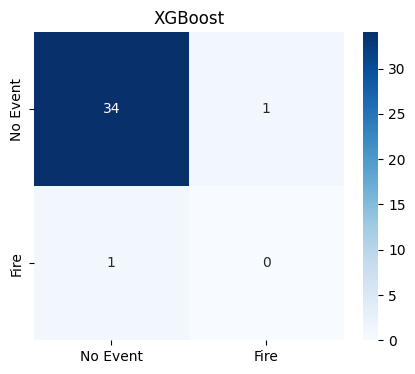

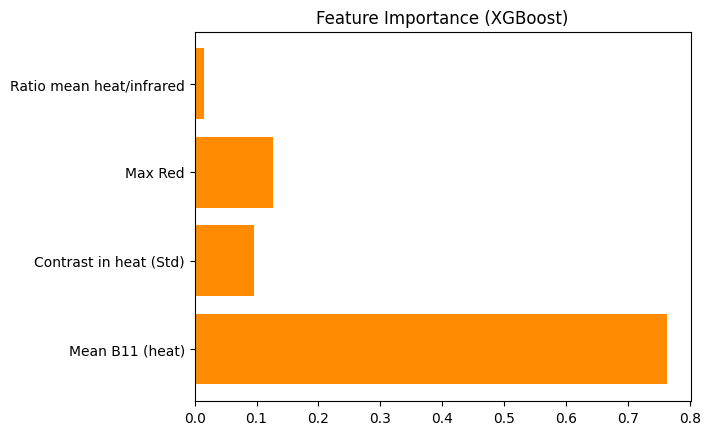

In [12]:
# ==========================================
# --- XGBOOST MODEL ---
# ==========================================

ratio = len(y_train[y_train == 0]) / (len(y_train[y_train == 1]) + 1)
xgb_model = XGBClassifier(n_estimators=100, scale_pos_weight=ratio, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print(f"\n--- RESULTS (feature engineering: {FEATURE_ENGINEERING}) ---")
print(classification_report(y_test, y_pred, target_names=['No Event', 'Fire']))

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Event', 'Fire'], yticklabels=['No Event', 'Fire'])
plt.title('XGBoost')
plt.show()

# feature importance
importances = xgb_model.feature_importances_
plt.barh(feature_names, importances, color='darkorange')
plt.title('Feature Importance (XGBoost)')
plt.show()